🔄 Loading data for Ostrava-Svinov...
   -> Detected Train Headers at Row 4
⚡ Generating Train Signals...
🚲 Calculating Bike Flows...
🎨 Plotting...


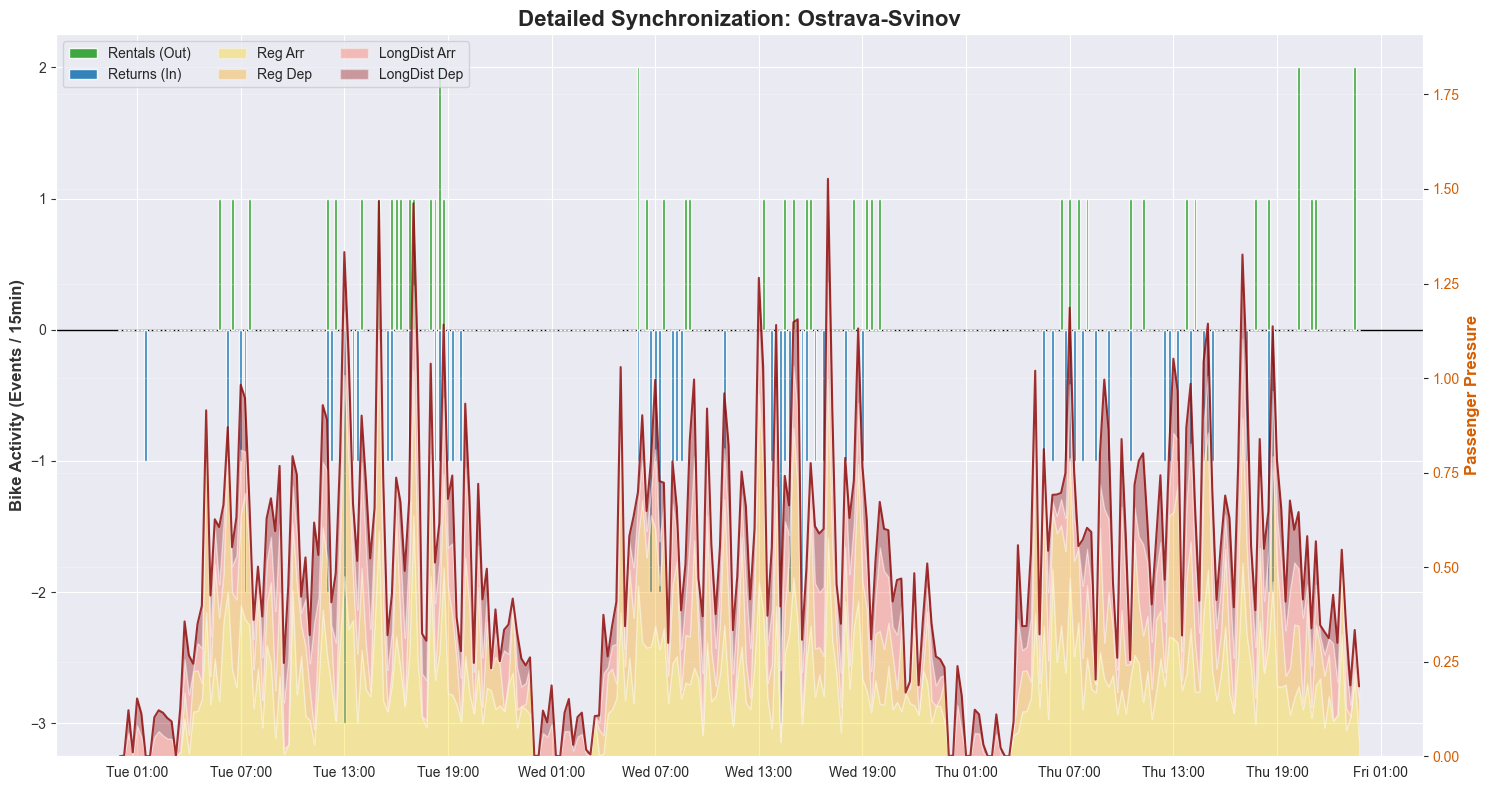

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy.signal.windows import gaussian

# ==========================================
# 0. HELPER FUNCTIONS (Inline replacement for transport_analytics)
# ==========================================
def standard_columns(df):
    """Renames Czech columns to standard English names."""
    rename_map = {
        'název bodu výběru': 'station', 'číslo vlaku': 'train_no',
        'druh vlaku': 'train_type', 'název výchozí stanice vlaku': 'origin',
        'název cílové stanice vlaku': 'destination', 'čas příjezdu': 'actual_arrival',
        'čas odjezdu': 'actual_departure', 'datum': 'date'
    }
    # Normalize columns to lowercase for easier matching
    df.columns = [str(c).lower().strip() for c in df.columns]

    new_cols = {}
    for col in df.columns:
        for key, val in rename_map.items():
            if key in col:
                new_cols[col] = val
                break
    return df.rename(columns=new_cols)

def generate_signals(trains, timeline, params):
    """Generates smoothed pressure signals."""
    s_arr = pd.Series(0.0, index=timeline)
    s_dep = pd.Series(0.0, index=timeline)
    weights = params.get('weights', {'Os': 1, 'Sp': 1, 'R': 1.5, 'Ex': 2})

    for _, train in trains.iterrows():
        w = weights.get(train.get('train_type', 'Os'), 1.0)
        # Arrival Signal
        if pd.notnull(train.get('actual_arrival')):
            try: s_arr.at[train['actual_arrival'].round('min')] += w
            except: pass
        # Departure Signal
        if pd.notnull(train.get('actual_departure')):
            try: s_dep.at[train['actual_departure'].round('min')] += w
            except: pass

    # Gaussian Smoothing
    window_size = 30
    gauss_kernel = gaussian(window_size, std=4)
    gauss_kernel /= gauss_kernel.sum()
    s_arr_smooth = pd.Series(np.convolve(s_arr.values, gauss_kernel, mode='same'), index=timeline)
    s_dep_smooth = pd.Series(np.convolve(s_dep.values, gauss_kernel, mode='same'), index=timeline)
    return s_arr_smooth, s_dep_smooth

# ==========================================
# 1. CONFIGURATION
# ==========================================
CITY_KEY = 'Ostrava-Svinov'
VIS_START = '2025-09-16 00:00'
VIS_END = '2025-09-18 23:59'

FILE_TRAINS = 'data/Pohyby_Svinov.xlsx'
FILE_BIKES = 'data/nextbike_data_VSB_Vaclavik.xlsx'
SHEET_RENTALS = 'Vypujcky_Ostrava'

STATION_CONFIG = {
    'train_station': 'Ostrava-Svinov',
    'bike_stations': ['SV-Svinov nádraží *(navíc 15min na odjezd)'],
    'params': {
        'weights': {'Os': 2.0, 'Sp': 1.7, 'R': 1.5, 'Ex': 1}
    }
}

# ==========================================
# 2. DATA LOADING & PROCESSING (FIXED)
# ==========================================
print(f"🔄 Loading data for {CITY_KEY}...")

# --- FIX: SMART HEADER DETECTION ---
# 1. Read first 20 rows to find where the header is
df_preview = pd.read_excel(FILE_TRAINS, header=None, nrows=20)
header_idx = 0
for idx, row in df_preview.iterrows():
    # Look for a row containing 'čas' (time) or 'vlak' (train)
    if any('čas' in str(x).lower() for x in row.values):
        header_idx = idx
        break

print(f"   -> Detected Train Headers at Row {header_idx}")

# 2. Load dataframe using the correct header row
df_trains = pd.read_excel(FILE_TRAINS, header=header_idx)
df_trains = standard_columns(df_trains)

# 3. Filter for correct station (if file contains multiple)
if 'station' in df_trains.columns:
    df_trains = df_trains[df_trains['station'].astype(str).str.contains(STATION_CONFIG['train_station'], case=False, na=False)]

# 4. Convert Times
df_trains['actual_arrival'] = pd.to_datetime(df_trains['actual_arrival'], errors='coerce')
df_trains['actual_departure'] = pd.to_datetime(df_trains['actual_departure'], errors='coerce')

# --- LOAD BIKES ---
df_bikes = pd.read_excel(FILE_BIKES, sheet_name=SHEET_RENTALS)
df_bikes.columns = [str(c).lower().strip() for c in df_bikes.columns]
df_bikes['start_time'] = pd.to_datetime(df_bikes['start_time'])
df_bikes['end_time'] = pd.to_datetime(df_bikes['end_time'])

# Setup Timeline
zoom_start = pd.to_datetime(VIS_START)
zoom_end = pd.to_datetime(VIS_END)
timeline_1min = pd.date_range(zoom_start, zoom_end, freq='1min')
timeline_15min = pd.date_range(zoom_start, zoom_end, freq='15min')

# ==========================================
# 3. GENERATE SEPARATE SIGNALS
# ==========================================
print("⚡ Generating Train Signals...")

t_mask = (df_trains['actual_arrival'] >= zoom_start) & (df_trains['actual_arrival'] <= zoom_end)
zoom_trains = df_trains[t_mask].copy()

# Split Categories
regional_types = ['Os', 'Sp']
ld_types = ['R', 'Ex', 'IC', 'EC', 'SC', 'rj']

df_reg = zoom_trains[zoom_trains['train_type'].isin(regional_types)]
df_ld = zoom_trains[zoom_trains['train_type'].isin(ld_types)]

# Generate Signals (using inline function)
s_arr_reg, s_dep_reg = generate_signals(df_reg, timeline_1min, STATION_CONFIG['params'])
s_arr_ld, s_dep_ld = generate_signals(df_ld, timeline_1min, STATION_CONFIG['params'])

# Resample to 15min
sig_reg_arr = s_arr_reg.resample('15min').mean()
sig_reg_dep = s_dep_reg.resample('15min').mean()
sig_ld_arr = s_arr_ld.resample('15min').mean()
sig_ld_dep = s_dep_ld.resample('15min').mean()

# ==========================================
# 4. CALCULATE BIKE FLOWS
# ==========================================
print("🚲 Calculating Bike Flows...")
valid_stations = [s.lower() for s in STATION_CONFIG['bike_stations']]
starts = df_bikes[df_bikes['start_place'].str.lower().isin(valid_stations)]
ends = df_bikes[df_bikes['end_place'].str.lower().isin(valid_stations)]

ts_rentals = starts.set_index('start_time').resample('15min').size().reindex(timeline_15min, fill_value=0)
ts_returns = ends.set_index('end_time').resample('15min').size().reindex(timeline_15min, fill_value=0) * -1

# ==========================================
# 5. VISUALIZATION
# ==========================================
print("🎨 Plotting...")
fig, ax1 = plt.subplots(figsize=(15, 8))

# --- LAYER 1: BIKE FLOWS ---
ax1.bar(timeline_15min, ts_rentals, width=0.007, color='#2ca02c', alpha=0.9, label='Rentals (Out)', align='center', zorder=3)
ax1.bar(timeline_15min, ts_returns, width=0.007, color='#1f77b4', alpha=0.9, label='Returns (In)', align='center', zorder=3)

ax1.axhline(0, color='black', linewidth=1)
ax1.set_ylabel('Bike Activity (Events / 15min)', fontsize=12, fontweight='bold', color='#333333')
ax1.tick_params(axis='y', colors='#333333')

# --- LAYER 2: TRAIN PRESSURE ---
ax2 = ax1.twinx()
x = timeline_15min
y_stack = [sig_reg_arr, sig_reg_dep, sig_ld_arr, sig_ld_dep]
labels = ['Reg Arr', 'Reg Dep', 'LongDist Arr', 'LongDist Dep']
colors = ['#FFD700', '#FFA500', '#FF6347', '#8B0000']

ax2.stackplot(x, y_stack, labels=labels, colors=colors, alpha=0.35, zorder=1)
total_pressure = sum(y_stack)
ax2.plot(x, total_pressure, color='#8B0000', linewidth=1.5, alpha=0.8, zorder=2, label='Total Pressure')

ax2.set_ylabel('Passenger Pressure', fontsize=12, fontweight='bold', color='#d55e00')
ax2.tick_params(axis='y', labelcolor='#d55e00')
if not isinstance(total_pressure, int) and not total_pressure.empty:
    ax2.set_ylim(0, total_pressure.max() * 1.25)

# --- FORMATTING ---
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%a %H:%M'))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.title(f"Detailed Synchronization: {CITY_KEY}", fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.25)

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2[:4], labels1 + labels2[:4], loc='upper left', ncol=3)

plt.tight_layout()
plt.show()